# PERSIAPAN LABORATORIUM
##### ============================================================================
### DOKTRIN: Functional Data Pipeline
- Semua impor dilakukan di sini, sekali jalan.
- Tidak ada state tersembunyi. Semua fungsi murni.
- Penamaan eksplisit, hindari huruf tunggal.
##### ============================================================================

In [2]:
import sys
import os 
from pathlib import Path

#### Menentukan akar proyek secara otomatis (idempotent)
#### Root adalah direktori yang berisi folder 'core' dan 'research'.

In [3]:
try:
    current_path = Path.cwd()
    if current_path.name == 'notebook' and current_path.parent.name == 'research':
        project_root = current_path.parent.parent
    else:
        project_root = current_path

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    print(f" Project root terdeteksi: {project_root}")

except Exception as e:
    print(f" Gagal mendeteksi root. periksa struktur directory/folder/. Error: {e}")


 Project root terdeteksi: /home/bumip/orca


##### ============================================================================
### PUSTAKA ANALITIK (semua diimpor dengan nama eksplisit)
##### ============================================================================

In [4]:
import os 
import sys
import time
from datetime import datetime
from typing import List, Dict, Any

# Third-party Lib (Data & Viz)
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import pandas as pd
"""
Local/Custom Core Engine (Black-box Layer)
Memastikan root project masuk ke sys.path jika dijalankan dari sub-folder
"""
sys.path.append(os.path.abspath(os.path.join('..')))

try:
    from core.signals.types import MarketObservation, SignalConfig
    from core.signals.strategies.kalman_mr import KalmanMeanReversion
    from core.math.kalman import KalmanConfig, AdaptationMode
    CORE_LOADED = True

except ImportError as e:
    CORE_LOADED = False
    print(f"Warning: Core component failed to load: {e}")

# Agar tidak ada warning menggangu saat experiment
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f"🚀 Environment Initialized at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



[FACTORY] 1. Starting Import Sequence...
[FACTORY] ✅ Import SUCCESS: <class 'core.signals.strategies.kalman_mr.KalmanMeanReversion'>

[SYSTEM] ⚡ Force-Registering Strategies...
[SYSTEM] ✅ Strategy Registration Complete.

🚀 Environment Initialized at: 2026-03-04 15:39:07


In [5]:
# ============================================================================
# RESEARCH & LAB VISUAL CONFIGURATION
# ============================================================================
def apply_lab_style():
    """ Mengatur estetika plot untuk kebutuhan publikasi/riset quant."""
    sns.set_theme(style="darkgrid", palette="muted")

    custom_params={
        'figure.figsize': (14, 7),
        'figure.dpi': 120,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 13,
        'lines.linewidth': 1.8,
        'legend.frameon': True,
        'savefig.bbox': 'tight',
        'savefig.dpi': 300  # High res untuk simpan gambar
    }

apply_lab_style()

In [6]:
# ============================================================================
# SYSTEM AUDIT (Explicit Version Check)
# ============================================================================
libraries = {
    "polars":  pl.__version__,
    "NumPy": np.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Python": sys.version.split()[0]
}
print("Lab Ready, Lib Audit:")
print("-" * 30)
for lib, version in libraries.items():
    print(f"{lib:<12} : v{version}")
print("-" * 30)
print(f"Core Engine Status: {'Loaded' if CORE_LOADED else 'Failed'}")

Lab Ready, Lib Audit:
------------------------------
polars       : v1.38.1
NumPy        : v2.4.2
Matplotlib   : v3.10.8
Seaborn      : v0.13.2
Python       : v3.11.14
------------------------------
Core Engine Status: Loaded


In [7]:
# ============================================================================
# RESEARCH & LAB VISUAL CONFIGURATION
# ============================================================================
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['savefig.dpi'] = 120

# ============================================================================
# Verifikasi versi
# ============================================================================
print("\n Lab Ready. Versi pustaka/Lib:")
print(f" Polars      :{pl.__version__}")
print(f" NumPy       :{np.__version__}")
print(f" Matplotlib  :{plt.matplotlib.__version__}")
print(f" Seaborn     :{sns.__version__}")


 Lab Ready. Versi pustaka/Lib:
 Polars      :1.38.1
 NumPy       :2.4.2
 Matplotlib  :3.10.8
 Seaborn     :0.13.2


✅ Data dimuat: 44640 baris, kolom: ['timestamp', 'close_DOGE', 'close_BTC']
   Spread dihitung, 44640 baris tersisa setelah drop nulls.

📊 Statistik deskriptif spread:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 44640.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ -13.173351 │
│ std        ┆ 0.048803   │
│ min        ┆ -13.316106 │
│ 25%        ┆ -13.191942 │
│ 50%        ┆ -13.177625 │
│ 75%        ┆ -13.148982 │
│ max        ┆ -13.043397 │
└────────────┴────────────┘


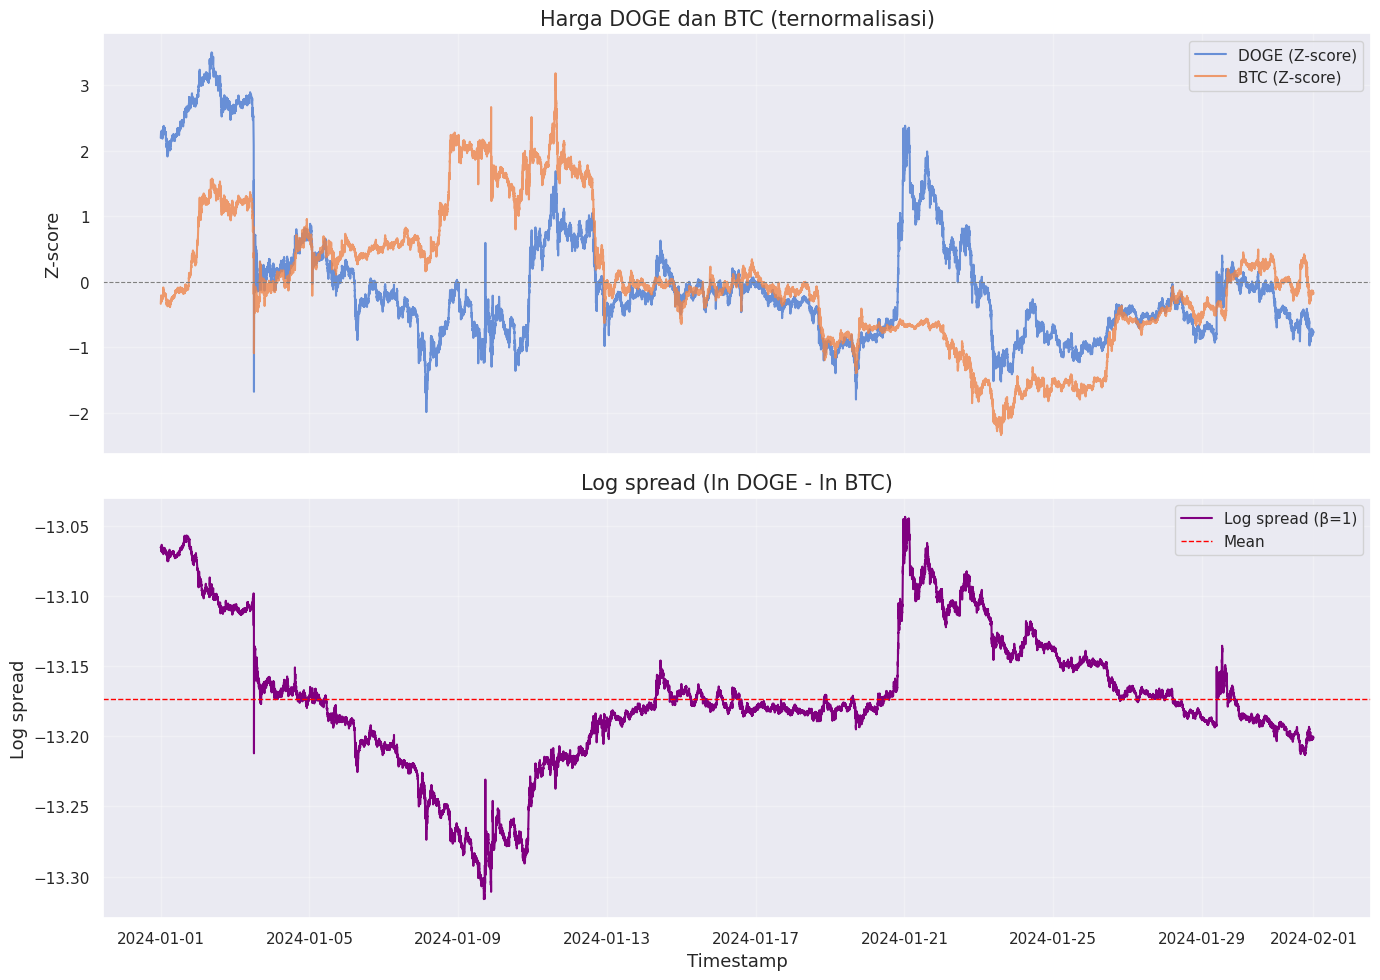


📈 Hasil Uji ADF:
   ADF Statistic     : -2.292319
   p‑value           : 0.174457
   Lag yang digunakan: 55
   Jumlah observasi  : 44584
   ❌ Kesimpulan: Gagal tolak H0. Spread tidak stasioner.
      Mungkin perlu hedge ratio berbeda atau transformasi lain.


In [13]:
# CELL 2: INGESTI DATA & UJI STASIONERITAS
# ============================================================================
# Memuat sampel data Silver Lake (Januari 2024) dan menguji sifat mean-reversion
# spread log dengan ADF test.
# Hipotesis: Data sudah bersih, spread dengan beta=1.0 bersifat stasioner.
# ============================================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# ----------------------------------------------------------------------------
# 1. Tentukan jalur data Silver (pastikan path sesuai sistem Anda)
# ----------------------------------------------------------------------------
silver_path = "/home/bumip/orca/data/silver/"

# ----------------------------------------------------------------------------
# 2. Muat data secara lazy dengan partisi Hive (tahun 2024, bulan 01)
# ----------------------------------------------------------------------------
data_lazy = (
    pl.scan_parquet(silver_path + "**/*.parquet", hive_partitioning=True)
    .filter(
        (pl.col("year") == "2024") & 
        (pl.col("month") == "01")
    )
    .select([
        "timestamp",
        "close_DOGE",
        "close_BTC"
    ])
)

# ----------------------------------------------------------------------------
# 3. Kumpulkan data ke memori (masih kecil, sebulan)
# ----------------------------------------------------------------------------
data_raw = data_lazy.collect()
print(f"✅ Data dimuat: {data_raw.shape[0]} baris, kolom: {data_raw.columns}")

# ----------------------------------------------------------------------------
# 4. Hitung log spread (beta = 1.0)
# ----------------------------------------------------------------------------
data_spread = data_raw.with_columns(
    (pl.col("close_DOGE").log() - pl.col("close_BTC").log()).alias("spread_log")
).drop_nulls()  # amankan jika ada null

print(f"   Spread dihitung, {data_spread.shape[0]} baris tersisa setelah drop nulls.")

# ----------------------------------------------------------------------------
# 5. Statistik deskriptif singkat
# ----------------------------------------------------------------------------
print("\n📊 Statistik deskriptif spread:")
print(data_spread["spread_log"].describe())

# ----------------------------------------------------------------------------
# 6. Visualisasi dua panel
# ----------------------------------------------------------------------------
# Normalisasi harga untuk perbandingan visual (Z‑score)
harga_normalized = data_spread.with_columns([
    ((pl.col("close_DOGE") - pl.col("close_DOGE").mean()) / pl.col("close_DOGE").std()).alias("doge_z"),
    ((pl.col("close_BTC") - pl.col("close_BTC").mean()) / pl.col("close_BTC").std()).alias("btc_z")
])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel atas: harga ternormalisasi
ax1.plot(harga_normalized["timestamp"], harga_normalized["doge_z"], 
         label="DOGE (Z‑score)", alpha=0.8, linewidth=1.5)
ax1.plot(harga_normalized["timestamp"], harga_normalized["btc_z"], 
         label="BTC (Z‑score)", alpha=0.8, linewidth=1.5)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_ylabel("Z‑score")
ax1.set_title("Harga DOGE dan BTC (ternormalisasi)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Panel bawah: log spread
ax2.plot(data_spread["timestamp"], data_spread["spread_log"], 
         color="purple", linewidth=1.5, label="Log spread (β=1)")
ax2.axhline(y=data_spread["spread_log"].mean(), color='red', 
            linestyle='--', linewidth=1, label="Mean")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Log spread")
ax2.set_title("Log spread (ln DOGE - ln BTC)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

if not os.path.exists('plot_result'):
    os.makedirs('plot_result')
plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/spread', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

# ----------------------------------------------------------------------------
# 7. Uji Augmented Dickey‑Fuller
# ----------------------------------------------------------------------------
spread_array = data_spread["spread_log"].to_numpy()
adf_result = adfuller(spread_array, autolag='AIC')

print("\n📈 Hasil Uji ADF:")
print(f"   ADF Statistic     : {adf_result[0]:.6f}")
print(f"   p‑value           : {adf_result[1]:.6f}")
print(f"   Lag yang digunakan: {adf_result[2]}")
print(f"   Jumlah observasi  : {adf_result[3]}")

# Interpretasi
if adf_result[1] < 0.05:
    print("   ✅ Kesimpulan: Tolak H0. Spread stasioner (mean‑reverting).")
    print("      Kalman Filter diperkirakan efektif.")
else:
    print("   ❌ Kesimpulan: Gagal tolak H0. Spread tidak stasioner.")
    print("      Mungkin perlu hedge ratio berbeda atau transformasi lain.")

# Simpan data spread untuk selanjutnya (tanpa mengubah data asli)
data_spread_clean = data_spread

In [9]:
data_spread_clean.write_csv("doge_btc_adf_020326.csv") 

# ESTIMASI VARIANS EMPIRIS – THE R ANCHOR
##### ============================================================================
- Menghitung rolling variance dari log spread untuk mendapatkan baseline
- Observation noices (R) bagi kalman Filter.
- Metodologi: rolling window → median sebagai anchor, persentil 5 dan 95
- sebagai batas wajar.
##### ============================================================================

In [10]:
"""
- Parameter jendela waktu (data disesuikan) 
- hitung rolling variance (variance berjalan) -- IDEMPOTEN 
"""
rolling_window = 60 // 2 #asusmiskan data per-menit * 60 * jam = rolling window dalam jam

# gunakan data dari operasi sebelumnya ( data spread clean )
data_variance = data_spread_clean.with_columns(
    pl.col("spread_log")
    .rolling_var(window_size=rolling_window)
    .alias("variance_rolling")
).drop_nulls(subset=["variance_rolling"])

print(f"Rolling variance dihitung dengan window {rolling_window}")
print(f"Jumlah data setelah drop nulls: {data_variance.shape[0]} baris")


Rolling variance dihitung dengan window 30
Jumlah data setelah drop nulls: 44611 baris


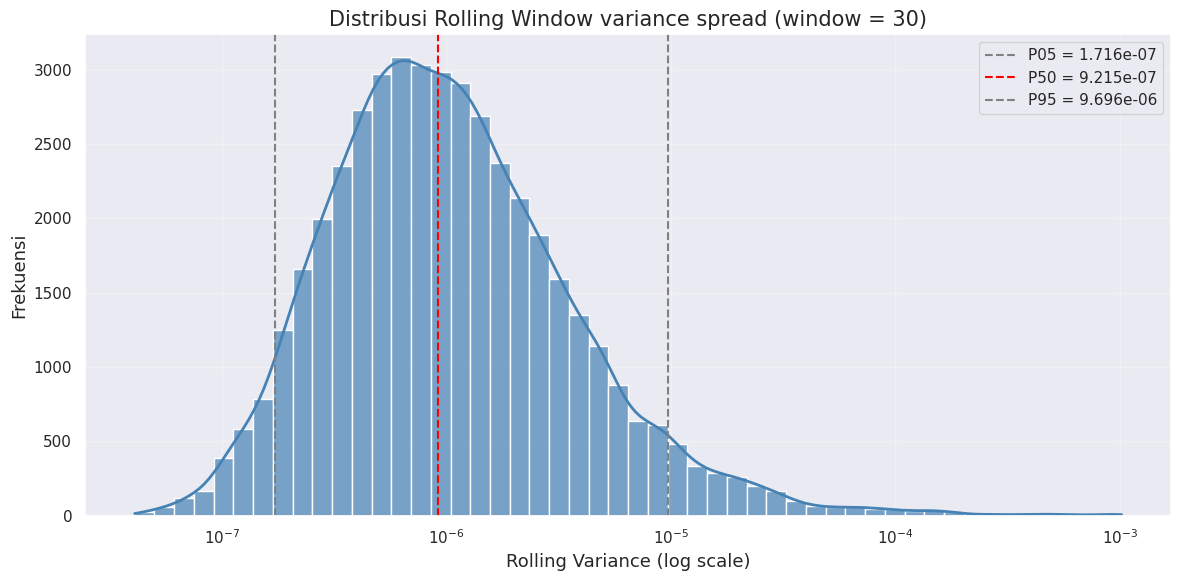

In [14]:
"""
- Ekstrak array variance dan hitung persentil
- Visualisasi histogram dengan skala log
"""
variance_array = data_variance["variance_rolling"].to_numpy()

variance_p05 = np.percentile(variance_array, 5)
variance_p50 = np.percentile(variance_array, 50)    # Mean atau Anchor R
variance_p95 = np.percentile(variance_array, 95)

fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(variance_array, bins=50, kde=True, log_scale=True, ax=ax,
            color='steelblue', alpha=0.7)
# Garis vertikal untuk persentil
ax.axvline(variance_p05, color='gray', linestyle='--', linewidth=1.5,
          label=f"P05 = {variance_p05:.3e}")
ax.axvline(variance_p50, color='red', linestyle='--', linewidth=1.5,
          label=f"P50 = {variance_p50:.3e}")
ax.axvline(variance_p95, color='gray', linestyle='--', linewidth=1.5,
          label=f"P95 = {variance_p95:.3e}")

ax.set_xlabel("Rolling Variance (log scale)")
ax.set_ylabel("Frekuensi")
ax.set_title(f"Distribusi Rolling Window variance spread (window = {rolling_window})")
ax.legend()
ax.grid(True, alpha=0.3)

if not os.path.exists('plot_result'):
    os.makedirs('plot_result')
plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/distr_rwvs_win30', dpi=300, bbox_inches='tight')
plt.show()

# UJI TRANSLASI AGNOSTIK – THE BRIDGE VALIDATION
##### ============================================================================
- Memastikan data tabular dapat dikonsumsi oleh mesin kalman tanpa crash -- kalman_mr ada di core/signals/strategies
- Menggunakan 500 baris pertama, dikemas sebagai class MarketObservation.
- Menangkap keluaran Z-score untuk memverfikasi bawa filter aktif
##### ============================================================================

In [60]:
try:
    # Ambil 500 baris pertama dari data_raw
    data_sample = data_raw.head(500)
    print(f"✅ Menggunakan {data_sample.shape[0]} baris dari data_raw.")
    print(f"   Kolom tersedia: {data_sample.columns}")
except NameError:
    # Fallback: buat data dummy jika data_raw tidak ditemukan
    print("⚠️ data_raw tidak ditemukan, membuat data dummy...")
    np.random.seed(42)
    timestamps = np.arange(1704067200000, 1704067200000 + 500 * 60000, 60000)  # 1 menit
    close_doge = 0.08 + np.cumsum(np.random.randn(500) * 0.0001)
    close_btc = 45000 + np.cumsum(np.random.randn(500) * 10)
    data_sample = pl.DataFrame({
        "timestamp": timestamps,
        "close_DOGE": close_doge,
        "close_BTC": close_btc
    })
    print("✅ Data dummy siap.")

✅ Menggunakan 500 baris dari data_raw.
   Kolom tersedia: ['timestamp', 'close_DOGE', 'close_BTC']


In [61]:
try:
    R_ANCHOR = variance_p50
    print(f"📊 Menggunakan R anchor dari estimasi: {R_ANCHOR:.6f}")
except NameError:
    R_ANCHOR = 0.001
    print(f"⚠️ variance_p50 tidak ditemukan, menggunakan R default: {R_ANCHOR}")

signal_config = SignalConfig(
    name="kalman_bridge_test",
    version="1.0.0",
    entry_z_score=2.0,
    exit_z_score=0.5,
    stop_loss_z=4.0,
    volatility_window=50,
    warmup_ticks=100
)

math_config = KalmanConfig(
    R=R_ANCHOR,
    Q=1e-5,
    initial_value=0.0,
    adaptation_mode=AdaptationMode.NIS_THRESHOLD
)

strategy = KalmanMeanReversion(
    signal_config=signal_config,
    math_config=math_config
)

print("✅ Strategi KalmanMeanReversion berhasil diinisialisasi.")

📊 Menggunakan R anchor dari estimasi: 0.000001
✅ Strategi KalmanMeanReversion berhasil diinisialisasi.


In [62]:
results = []
z_scores = []
signal_types = []

print("⏳ Memproses 500 baris...")
start_time = datetime.now()

for idx, row in enumerate(data_sample.iter_rows(named=True)):
    # Konversi timestamp
    ts_raw = row["timestamp"]
    if isinstance(ts_raw, (int, float, np.integer, np.floating)):
        ts = int(ts_raw)
    elif isinstance(ts_raw, datetime):
        ts = int(ts_raw.timestamp() * 1000)
    else:
        try:
            ts = int(ts_raw)
        except:
            print(f"⚠️ Baris {idx}: timestamp tidak dikenal, gunakan 0")
            ts = 0

    try:
        close_doge = float(row["close_DOGE"])
        close_btc = float(row["close_BTC"])
    except:
        print(f"❌ Baris {idx}: error konversi harga, lewati")
        continue

    obs_dict = {
        "timestamp": ts,
        "close_DOGE": close_doge,
        "close_BTC": close_btc
    }

    result = strategy.evaluate_state(obs_dict)

    if result.is_ok():
        signal = result.unwrap()
        meta = signal.metadata
        z = meta.get("zscore", np.nan)
        z_scores.append(z)
        signal_types.append(signal.signal_type.name)

        results.append({
            "timestamp": signal.timestamp,
            "signal": signal.signal_type.name,
            "strength": signal.strength,
            "zscore": z,
            "spread": meta.get("spread", np.nan),
            "estimate": meta.get("estimate", np.nan),
            "volatility": meta.get("volatility", np.nan),
            "factor_q": meta.get("factor_q", 1.0),
            "status": meta.get("status", "active")
        })
    else:
        error_msg = result.unwrap_err()
        print(f"❌ Error pada baris {idx}: {error_msg}")
        z_scores.append(np.nan)
        signal_types.append("ERROR")
        results.append({
            "timestamp": ts,
            "signal": "ERROR",
            "strength": 0.0,
            "zscore": np.nan,
            "spread": np.nan,
            "estimate": np.nan,
            "volatility": np.nan,
            "factor_q": 1.0,
            "status": "error",
            "error": error_msg
        })

elapsed = (datetime.now() - start_time).total_seconds()
print(f"✅ Selesai dalam {elapsed:.2f} detik.")

⏳ Memproses 500 baris...
✅ Selesai dalam 0.01 detik.



📊 RINGKASAN HASIL UJI BRIDGE
Total baris diproses      : 500
Jumlah sinyal sukses      : 500
Jumlah error              : 0

📈 Statistik spread dari metadata:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: spread, dtype: float64
⚠️ Tidak ada z-score valid.

📊 Distribusi sinyal:
   NEUTRAL    :  500 (100.0%)

⚠️ Filter TIDAK AKTIF: Tidak ada sinyal non-NEUTRAL setelah warmup.

🔍 Statistik spread manual (log DOGE - log BTC):
count    500.000000
mean     -13.068727
std        0.002252
min      -13.075080
25%      -13.069872
50%      -13.068842
75%      -13.067134
max      -13.063344
dtype: float64


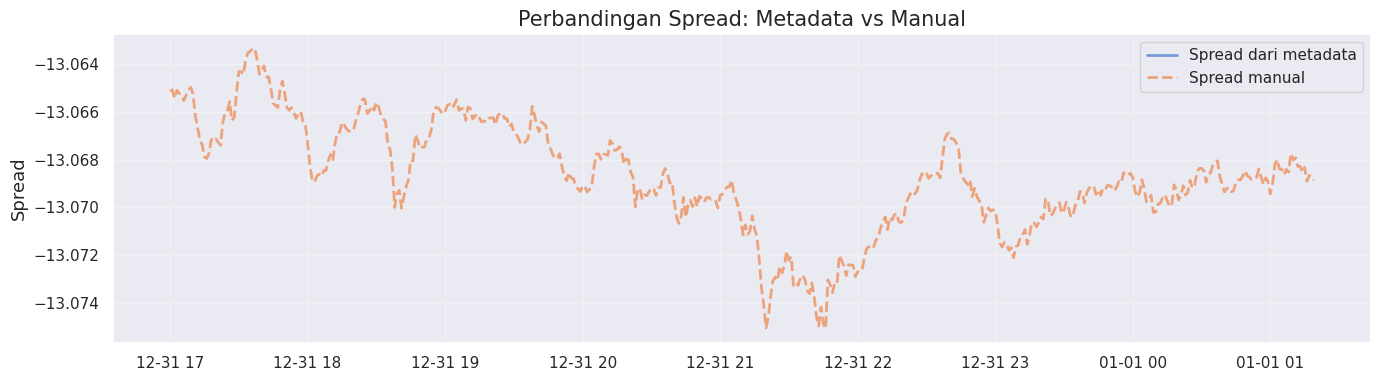

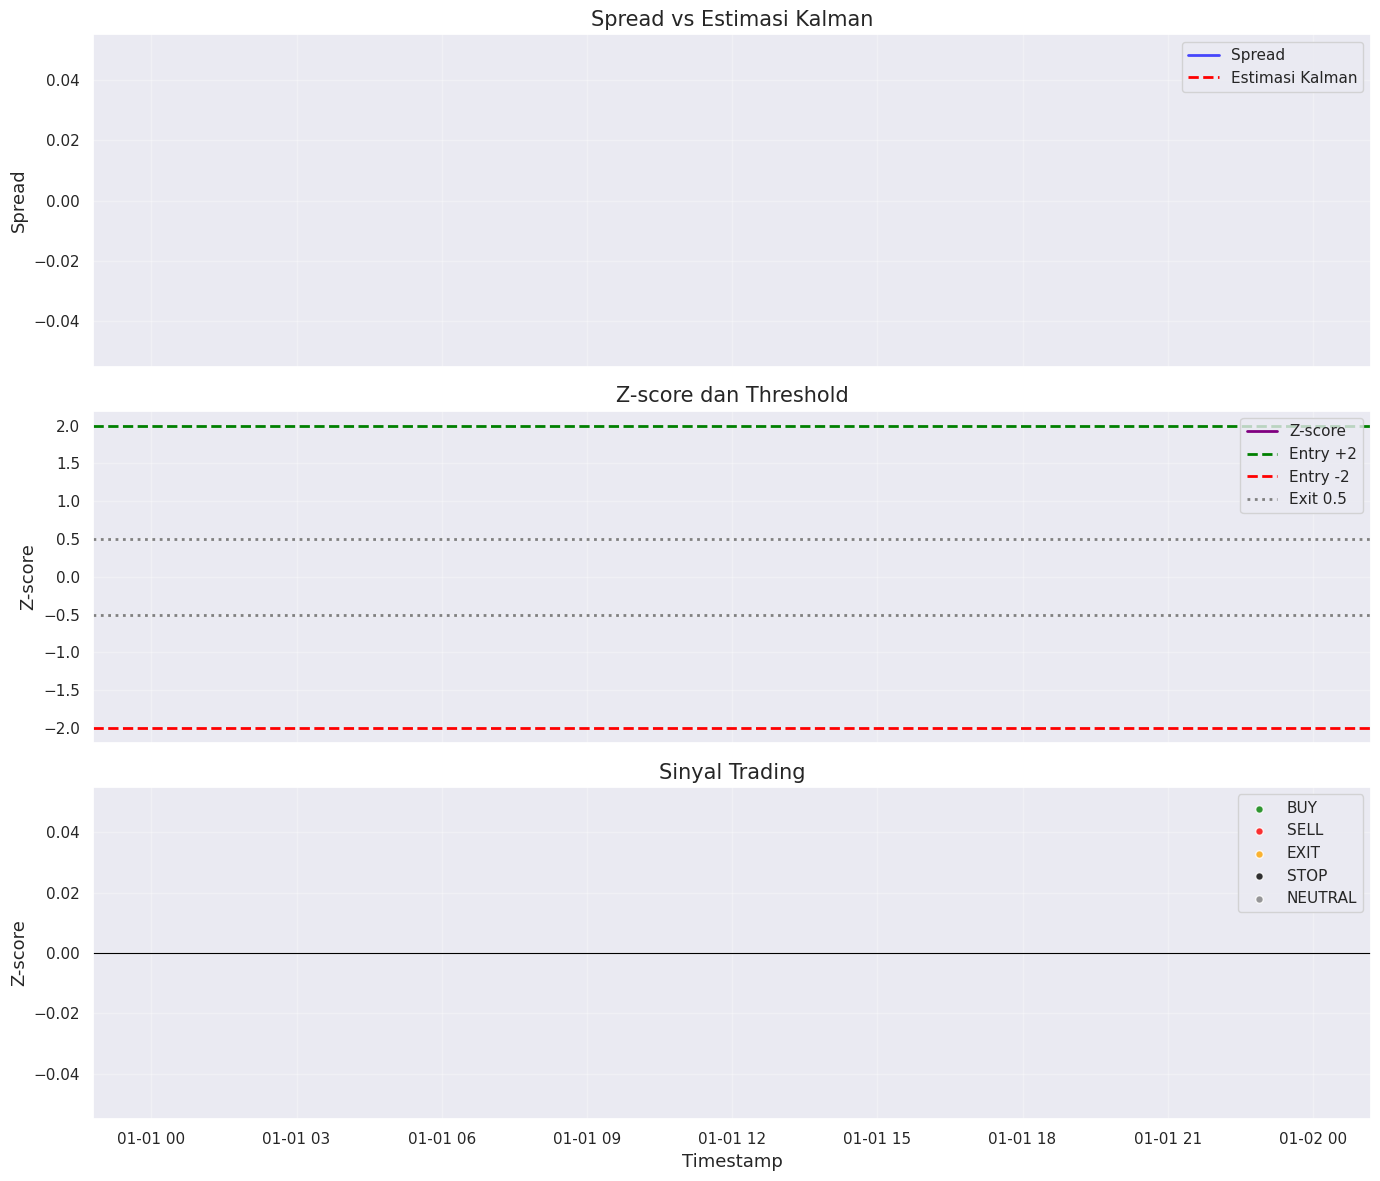


💾 Hasil debugging disimpan.

🎉 UJI TRANSLASI AGNOSTIK SELESAI.


In [63]:
df_results = pd.DataFrame(results)
df_results['timestamp'] = pd.to_datetime(df_results['timestamp'], unit='ms')

print("\n📊 RINGKASAN HASIL UJI BRIDGE")
print("=" * 50)
print(f"Total baris diproses      : {len(df_results)}")
print(f"Jumlah sinyal sukses      : {len(df_results[df_results['signal'] != 'ERROR'])}")
print(f"Jumlah error              : {len(df_results[df_results['signal'] == 'ERROR'])}")

# Statistik spread (untuk memeriksa apakah spread bervariasi)
print("\n📈 Statistik spread dari metadata:")
print(df_results['spread'].describe())

# Statistik z-score
valid_z = df_results['zscore'].dropna()
if len(valid_z) > 0:
    print(f"\n📈 Statistik Z-score (valid):")
    print(valid_z.describe())
    print(f"   |z| > 2.0 : {(np.abs(valid_z) > 2.0).sum()} observasi")
else:
    print("⚠️ Tidak ada z-score valid.")

# Distribusi sinyal
print("\n📊 Distribusi sinyal:")
signal_counts = df_results['signal'].value_counts()
for sig, cnt in signal_counts.items():
    pct = 100 * cnt / len(df_results)
    print(f"   {sig:10} : {cnt:4} ({pct:.1f}%)")

# Verifikasi filter aktif
warmup = strategy.WARMUP_REQUIRED
if len(df_results) > warmup:
    after_warmup = df_results.iloc[warmup:]
    non_neutral = after_warmup[~after_warmup['signal'].isin(['NEUTRAL', 'ERROR'])]
    if len(non_neutral) > 0:
        print(f"\n✅ Filter AKTIF: {len(non_neutral)} sinyal non-NEUTRAL setelah warmup.")
        # Tampilkan beberapa baris pertama setelah warmup
        print("\n🔍 Contoh sinyal setelah warmup (10 baris pertama):")
        print(after_warmup[['timestamp', 'signal', 'zscore', 'spread']].head(10))
    else:
        print("\n⚠️ Filter TIDAK AKTIF: Tidak ada sinyal non-NEUTRAL setelah warmup.")
else:
    print(f"\n⚠️ Data terlalu pendek ({len(df_results)} baris) untuk melewati warmup ({warmup}).")

# ----------------------------------------------------------------------------
# 5. HITUNG SPREAD MANUAL UNTUK PERBANDINGAN
# ----------------------------------------------------------------------------
spread_manual = []
for row in data_sample.iter_rows(named=True):
    try:
        log_doge = np.log(float(row["close_DOGE"]))
        log_btc = np.log(float(row["close_BTC"]))
        spread_manual.append(log_doge - log_btc)
    except:
        spread_manual.append(np.nan)

print("\n🔍 Statistik spread manual (log DOGE - log BTC):")
print(pd.Series(spread_manual).describe())

# Visualisasi perbandingan spread dari metadata vs manual
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_results['timestamp'], df_results['spread'], label='Spread dari metadata', alpha=0.7)
ax.plot(df_results['timestamp'], spread_manual[:len(df_results)], label='Spread manual', alpha=0.7, linestyle='--')
ax.set_ylabel('Spread')
ax.set_title('Perbandingan Spread: Metadata vs Manual')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 6. VISUALISASI Z-SCORE DAN SPREAD
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Spread dan estimasi Kalman
axes[0].plot(df_results['timestamp'], df_results['spread'], label='Spread', color='blue', alpha=0.7)
axes[0].plot(df_results['timestamp'], df_results['estimate'], label='Estimasi Kalman', color='red', linestyle='--')
axes[0].set_ylabel('Spread')
axes[0].set_title('Spread vs Estimasi Kalman')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Z-score
axes[1].plot(df_results['timestamp'], df_results['zscore'], color='purple', label='Z-score')
axes[1].axhline(y=2.0, color='green', linestyle='--', label='Entry +2')
axes[1].axhline(y=-2.0, color='red', linestyle='--', label='Entry -2')
axes[1].axhline(y=0.5, color='gray', linestyle=':', label='Exit 0.5')
axes[1].axhline(y=-0.5, color='gray', linestyle=':')
axes[1].set_ylabel('Z-score')
axes[1].set_title('Z-score dan Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Sinyal
colors = {'BUY': 'green', 'SELL': 'red', 'EXIT': 'orange', 'STOP': 'black', 'NEUTRAL': 'gray'}
for sig, color in colors.items():
    mask = df_results['signal'] == sig
    axes[2].scatter(df_results.loc[mask, 'timestamp'], 
                    df_results.loc[mask, 'zscore'], 
                    color=color, label=sig, s=30, alpha=0.8, edgecolors='white')
axes[2].axhline(y=0, color='black', linewidth=0.8)
axes[2].set_ylabel('Z-score')
axes[2].set_xlabel('Timestamp')
axes[2].set_title('Sinyal Trading')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/bridge_validation_debug.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# 7. SIMPAN HASIL
# ----------------------------------------------------------------------------
df_results.to_csv('/home/bumip/orca/research/notebook/plot_result/bridge_results_debug.csv', index=False)
print("\n💾 Hasil debugging disimpan.")

print("\n🎉 UJI TRANSLASI AGNOSTIK SELESAI.")

✅ Menggunakan 500 baris dari data_raw.
   Kolom tersedia: ['timestamp', 'close_DOGE', 'close_BTC']
📊 Menggunakan R anchor dari estimasi: 0.000001
✅ Strategi KalmanMeanReversion berhasil diinisialisasi.
⏳ Memproses 500 baris...
✅ Selesai dalam 0.01 detik.

📊 RINGKASAN HASIL UJI BRIDGE
Total baris diproses      : 500
Jumlah sinyal sukses      : 500
Jumlah error              : 0

📈 Statistik spread:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: spread, dtype: float64
⚠️ Tidak ada z-score valid.

📊 Distribusi sinyal:
   NEUTRAL    :  500 (100.0%)

⚠️ Filter TIDAK AKTIF: Tidak ada sinyal non-NEUTRAL setelah warmup.


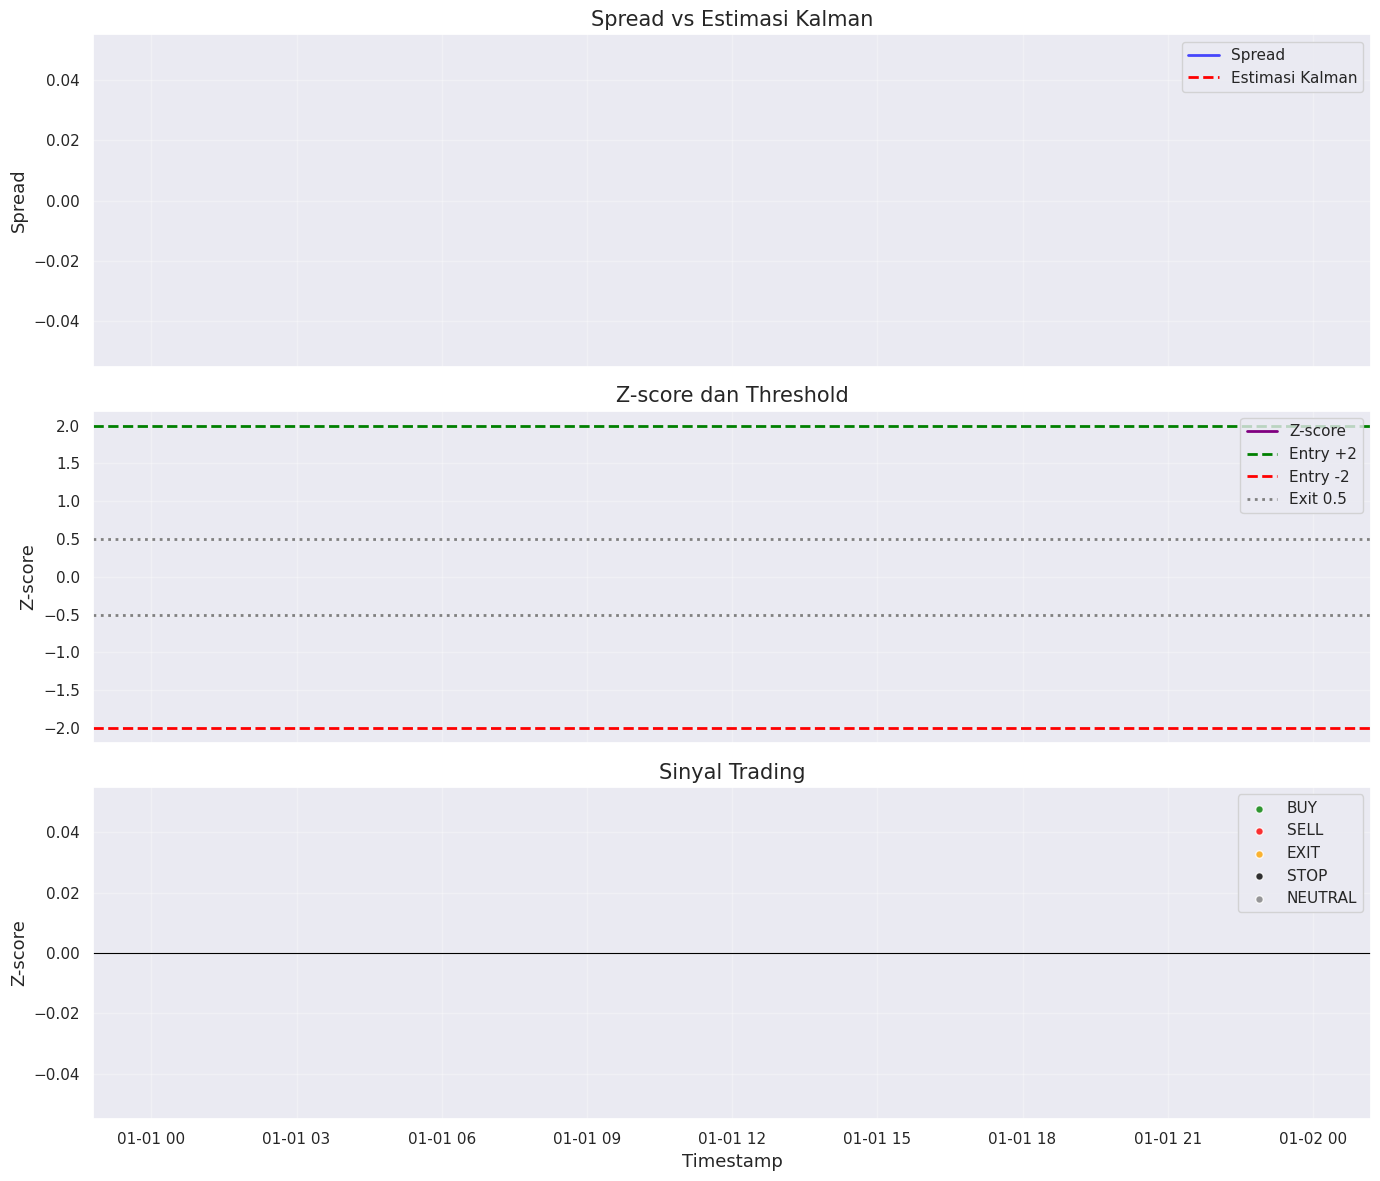


💾 Hasil disimpan ke plot_result/bridge_results_fixed.csv

🎉 UJI TRANSLASI AGNOSTIK SELESAI.


In [64]:
# UJI TRANSLASI AGNOSTIK – THE BRIDGE VALIDATION (FIXED dengan spread manual)
# ============================================================================
# Memastikan data tabular dapat dikonsumsi oleh mesin kalman tanpa crash
# Menggunakan 500 baris pertama dari data silver (Januari 2024)
# ============================================================================

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from datetime import datetime

# ----------------------------------------------------------------------------
# 1. PERSIAPAN DATA (500 baris pertama)
# ----------------------------------------------------------------------------
try:
    data_sample = data_raw.head(500)
    print(f"✅ Menggunakan {data_sample.shape[0]} baris dari data_raw.")
    print(f"   Kolom tersedia: {data_sample.columns}")
except NameError:
    print("⚠️ data_raw tidak ditemukan, membuat data dummy...")
    np.random.seed(42)
    timestamps = np.arange(1704067200000, 1704067200000 + 500 * 60000, 60000)
    close_doge = 0.08 + np.cumsum(np.random.randn(500) * 0.0001)
    close_btc = 45000 + np.cumsum(np.random.randn(500) * 10)
    data_sample = pl.DataFrame({
        "timestamp": timestamps,
        "close_DOGE": close_doge,
        "close_BTC": close_btc
    })
    print("✅ Data dummy siap.")

# ----------------------------------------------------------------------------
# 2. KONFIGURASI STRATEGI
# ----------------------------------------------------------------------------
try:
    R_ANCHOR = variance_p50
    print(f"📊 Menggunakan R anchor dari estimasi: {R_ANCHOR:.6f}")
except NameError:
    R_ANCHOR = 0.001
    print(f"⚠️ variance_p50 tidak ditemukan, menggunakan R default: {R_ANCHOR}")

signal_config = SignalConfig(
    name="kalman_bridge_test",
    version="1.0.0",
    entry_z_score=2.0,
    exit_z_score=0.5,
    stop_loss_z=4.0,
    volatility_window=50,
    warmup_ticks=100
)

math_config = KalmanConfig(
    R=R_ANCHOR,
    Q=1e-5,
    initial_value=0.0,
    adaptation_mode=AdaptationMode.NIS_THRESHOLD
)

strategy = KalmanMeanReversion(
    signal_config=signal_config,
    math_config=math_config
)

print("✅ Strategi KalmanMeanReversion berhasil diinisialisasi.")

# ----------------------------------------------------------------------------
# 3. PROSES TIAP BARIS DENGAN SPREAD MANUAL
# ----------------------------------------------------------------------------
results = []
z_scores = []
signal_types = []

print("⏳ Memproses 500 baris...")
start_time = datetime.now()

for idx, row in enumerate(data_sample.iter_rows(named=True)):
    # Konversi timestamp
    ts_raw = row["timestamp"]
    if isinstance(ts_raw, (int, float, np.integer, np.floating)):
        ts = int(ts_raw)
    elif isinstance(ts_raw, datetime):
        ts = int(ts_raw.timestamp() * 1000)
    else:
        try:
            ts = int(ts_raw)
        except:
            print(f"⚠️ Baris {idx}: timestamp tidak dikenal, gunakan 0")
            ts = 0

    try:
        close_doge = float(row["close_DOGE"])
        close_btc = float(row["close_BTC"])
    except:
        print(f"❌ Baris {idx}: error konversi harga, lewati")
        continue

    # Hitung spread manual
    log_doge = np.log(close_doge)
    log_btc = np.log(close_btc)
    spread = log_doge - log_btc

    # Tambahkan key 'spread' ke dictionary agar _extract_spread langsung mengenali
    obs_dict = {
        "timestamp": ts,
        "close_DOGE": close_doge,
        "close_BTC": close_btc,
        "spread": spread
    }

    result = strategy.evaluate_state(obs_dict)

    if result.is_ok():
        signal = result.unwrap()
        meta = signal.metadata
        z = meta.get("zscore", np.nan)
        z_scores.append(z)
        signal_types.append(signal.signal_type.name)

        results.append({
            "timestamp": signal.timestamp,
            "signal": signal.signal_type.name,
            "strength": signal.strength,
            "zscore": z,
            "spread": meta.get("spread", np.nan),
            "estimate": meta.get("estimate", np.nan),
            "volatility": meta.get("volatility", np.nan),
            "factor_q": meta.get("factor_q", 1.0),
            "status": meta.get("status", "active")
        })
    else:
        error_msg = result.unwrap_err()
        print(f"❌ Error pada baris {idx}: {error_msg}")
        z_scores.append(np.nan)
        signal_types.append("ERROR")
        results.append({
            "timestamp": ts,
            "signal": "ERROR",
            "strength": 0.0,
            "zscore": np.nan,
            "spread": spread,  # tetap catat spread
            "estimate": np.nan,
            "volatility": np.nan,
            "factor_q": 1.0,
            "status": "error",
            "error": error_msg
        })

elapsed = (datetime.now() - start_time).total_seconds()
print(f"✅ Selesai dalam {elapsed:.2f} detik.")

# ----------------------------------------------------------------------------
# 4. ANALISIS HASIL
# ----------------------------------------------------------------------------
df_results = pd.DataFrame(results)
df_results['timestamp'] = pd.to_datetime(df_results['timestamp'], unit='ms')

print("\n📊 RINGKASAN HASIL UJI BRIDGE")
print("=" * 50)
print(f"Total baris diproses      : {len(df_results)}")
print(f"Jumlah sinyal sukses      : {len(df_results[df_results['signal'] != 'ERROR'])}")
print(f"Jumlah error              : {len(df_results[df_results['signal'] == 'ERROR'])}")

# Statistik spread (seharusnya tidak NaN)
print("\n📈 Statistik spread:")
print(df_results['spread'].describe())

# Statistik z-score
valid_z = df_results['zscore'].dropna()
if len(valid_z) > 0:
    print(f"\n📈 Statistik Z-score (valid):")
    print(valid_z.describe())
    print(f"   |z| > 2.0 : {(np.abs(valid_z) > 2.0).sum()} observasi")
else:
    print("⚠️ Tidak ada z-score valid.")

# Distribusi sinyal
print("\n📊 Distribusi sinyal:")
signal_counts = df_results['signal'].value_counts()
for sig, cnt in signal_counts.items():
    pct = 100 * cnt / len(df_results)
    print(f"   {sig:10} : {cnt:4} ({pct:.1f}%)")

# Verifikasi filter aktif
warmup = strategy.WARMUP_REQUIRED
if len(df_results) > warmup:
    after_warmup = df_results.iloc[warmup:]
    non_neutral = after_warmup[~after_warmup['signal'].isin(['NEUTRAL', 'ERROR'])]
    if len(non_neutral) > 0:
        print(f"\n✅ Filter AKTIF: {len(non_neutral)} sinyal non-NEUTRAL setelah warmup.")
        print("\n🔍 Contoh sinyal setelah warmup (10 baris pertama):")
        print(after_warmup[['timestamp', 'signal', 'zscore', 'spread']].head(10))
    else:
        print("\n⚠️ Filter TIDAK AKTIF: Tidak ada sinyal non-NEUTRAL setelah warmup.")
else:
    print(f"\n⚠️ Data terlalu pendek ({len(df_results)} baris) untuk melewati warmup ({warmup}).")

# ----------------------------------------------------------------------------
# 5. VISUALISASI Z-SCORE DAN SPREAD
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Spread dan estimasi Kalman
axes[0].plot(df_results['timestamp'], df_results['spread'], label='Spread', color='blue', alpha=0.7)
axes[0].plot(df_results['timestamp'], df_results['estimate'], label='Estimasi Kalman', color='red', linestyle='--')
axes[0].set_ylabel('Spread')
axes[0].set_title('Spread vs Estimasi Kalman')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Z-score
axes[1].plot(df_results['timestamp'], df_results['zscore'], color='purple', label='Z-score')
axes[1].axhline(y=2.0, color='green', linestyle='--', label='Entry +2')
axes[1].axhline(y=-2.0, color='red', linestyle='--', label='Entry -2')
axes[1].axhline(y=0.5, color='gray', linestyle=':', label='Exit 0.5')
axes[1].axhline(y=-0.5, color='gray', linestyle=':')
axes[1].set_ylabel('Z-score')
axes[1].set_title('Z-score dan Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Sinyal
colors = {'BUY': 'green', 'SELL': 'red', 'EXIT': 'orange', 'STOP': 'black', 'NEUTRAL': 'gray'}
for sig, color in colors.items():
    mask = df_results['signal'] == sig
    axes[2].scatter(df_results.loc[mask, 'timestamp'], 
                    df_results.loc[mask, 'zscore'], 
                    color=color, label=sig, s=30, alpha=0.8, edgecolors='white')
axes[2].axhline(y=0, color='black', linewidth=0.8)
axes[2].set_ylabel('Z-score')
axes[2].set_xlabel('Timestamp')
axes[2].set_title('Sinyal Trading')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/bridge_validation_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# 6. SIMPAN HASIL
# ----------------------------------------------------------------------------
df_results.to_csv('/home/bumip/orca/research/notebook/plot_result/bridge_results_fixed.csv', index=False)
print("\n💾 Hasil disimpan ke plot_result/bridge_results_fixed.csv")

print("\n🎉 UJI TRANSLASI AGNOSTIK SELESAI.")